# Q5 - Lamp placement in a dark room

We place lamps in the unit square $[0,1]^2$ and maximize the average room brightness while penalizing lamps that collapse onto one another. The optimization objective is

$$J = \frac{1}{|G|}\sum_{p\in G}\sum_{k=1}^{n} \exp\left(-\frac{\|p-l_k\|^2}{2\sigma^2}\right) - \lambda\sum_{i<j}\exp\left(-\frac{\|l_i-l_j\|^2}{2\rho^2}\right).$$

PyTorch minimizes losses, so we optimize `-J`. Lamp locations are clamped to the room after each Adam step.

In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

torch.set_default_dtype(torch.float64)
DEVICE = torch.device('cpu')
OUTPUT_DIR = Path('lamp_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

SIGMA = 0.25
RHO = 0.20
LAMBDA = 1.0
GRID_SIZE = 60
STEPS = 500
LEARNING_RATE = 0.08

print(f'PyTorch {torch.__version__}; device={DEVICE}')

PyTorch 2.13.0+cpu; device=cpu


## Differentiable objective

The grid is only used to approximate the room integral. Pairwise repulsion is computed directly between lamp coordinates.

In [9]:
def make_room_grid(size=GRID_SIZE):
    axis = torch.linspace(0.0, 1.0, size, device=DEVICE)
    yy, xx = torch.meshgrid(axis, axis, indexing='ij')
    return torch.stack((xx, yy), dim=-1).reshape(-1, 2)

ROOM_GRID = make_room_grid()

def brightness_map(lamps, grid=ROOM_GRID, sigma=SIGMA):
    squared_distances = ((grid[:, None, :] - lamps[None, :, :]) ** 2).sum(dim=-1)
    contributions = torch.exp(-squared_distances / (2.0 * sigma ** 2))
    return contributions.sum(dim=1)

def repulsion(lamps, rho=RHO):
    pairwise_squared_distances = ((lamps[:, None, :] - lamps[None, :, :]) ** 2).sum(dim=-1)
    pair_mask = torch.triu(torch.ones_like(pairwise_squared_distances), diagonal=1).bool()
    return torch.exp(-pairwise_squared_distances / (2.0 * rho ** 2))[pair_mask].sum()

def objective(lamps, grid=ROOM_GRID, sigma=SIGMA, rho=RHO, lam=LAMBDA):
    brightness = brightness_map(lamps, grid, sigma).mean()
    penalty = repulsion(lamps, rho)
    return brightness - lam * penalty, brightness, penalty

The helper below keeps every optimization trajectory, making it possible to render the lamps moving over time.

In [3]:
def optimize_lamps(num_lamps=3, seed=0, steps=STEPS, learning_rate=LEARNING_RATE,
                   sigma=SIGMA, rho=RHO, lam=LAMBDA):
    torch.manual_seed(seed)
    lamps = torch.rand((num_lamps, 2), device=DEVICE, requires_grad=True)
    optimizer = torch.optim.Adam([lamps], lr=learning_rate)
    trajectory = [lamps.detach().cpu().numpy().copy()]
    objective_history = []

    for step in range(steps):
        optimizer.zero_grad()
        value, brightness, penalty = objective(lamps, sigma=sigma, rho=rho, lam=lam)
        (-value).backward()
        optimizer.step()
        with torch.no_grad():
            lamps.clamp_(0.0, 1.0)
        objective_history.append((value.item(), brightness.item(), penalty.item()))
        if step == 0 or (step + 1) % 5 == 0:
            trajectory.append(lamps.detach().cpu().numpy().copy())

    return {
        'lamps': lamps.detach().cpu(),
        'trajectory': np.asarray(trajectory),
        'history': np.asarray(objective_history),
        'seed': seed,
        'num_lamps': num_lamps,
    }

def map_array(lamps, size=GRID_SIZE):
    values = brightness_map(lamps, make_room_grid(size)).reshape(size, size)
    return values.detach().cpu().numpy()

def plot_brightness(result, title='Brightness map'):
    lamps = result['lamps']
    values = map_array(lamps)
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(values, origin='lower', extent=(0, 1, 0, 1), cmap='magma')
    ax.scatter(lamps[:, 0], lamps[:, 1], c='cyan', edgecolors='white', s=90, label='lamps')
    ax.set(xlabel='x', ylabel='y', title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc='upper right')
    fig.colorbar(image, ax=ax, label='brightness')
    fig.tight_layout()
    return fig, ax

def save_trajectory_gif(result, path, interval=70):
    trajectory = result['trajectory']
    values = map_array(torch.tensor(trajectory[0]))
    fig, ax = plt.subplots(figsize=(5, 5))
    image = ax.imshow(values, origin='lower', extent=(0, 1, 0, 1), cmap='magma', vmin=0, vmax=result['num_lamps'])
    points = ax.scatter([], [], c='cyan', edgecolors='white', s=90)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x', ylabel='y')
    title = ax.set_title('')

    def update(frame):
        current = torch.tensor(trajectory[frame])
        image.set_data(map_array(current))
        points.set_offsets(trajectory[frame])
        title.set_text(f'{result["num_lamps"]} lamps, optimization frame {frame + 1}/{len(trajectory)}')
        return image, points, title

    animation = FuncAnimation(fig, update, frames=len(trajectory), interval=interval, blit=False)
    animation.save(path, writer=PillowWriter(fps=12))
    plt.close(fig)
    return path

In [10]:
# Cheap smoke test: one short run should produce finite values and valid coordinates.
smoke = optimize_lamps(num_lamps=3, seed=123, steps=3)
assert torch.isfinite(smoke['lamps']).all()
assert ((smoke['lamps'] >= 0) & (smoke['lamps'] <= 1)).all()
assert np.isfinite(smoke['history']).all()
print('Smoke test passed:', smoke['lamps'].numpy())

Smoke test passed: [[0.16521694 0.        ]
 [0.79894271 0.32619447]
 [0.29275975 0.72353515]]


## Three lamps: before and after optimization

The initial state is shown beside the optimized state for one random seed.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13436\2421196892.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


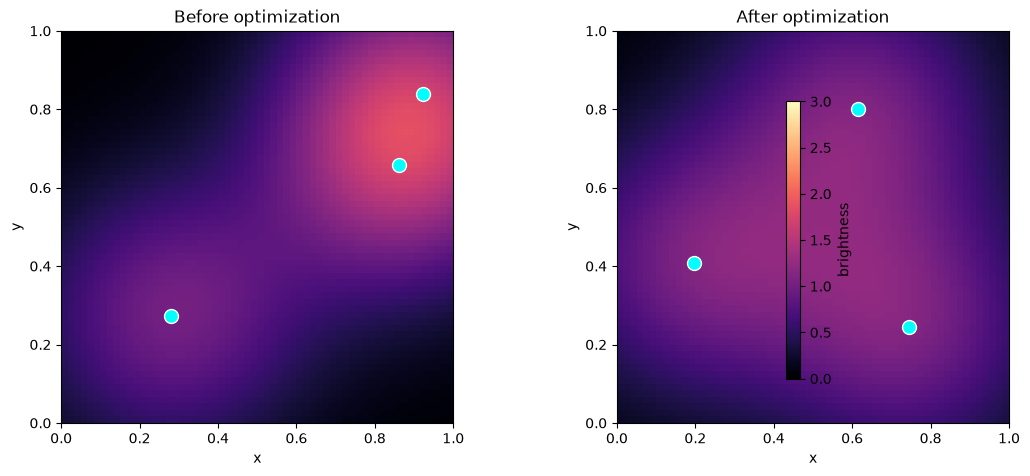

Final J=0.7906; brightness=0.8411; repulsion penalty=0.0505
Final lamp positions:
 [[0.19732784 0.40773251]
 [0.74463699 0.24453461]
 [0.61412234 0.80052545]]


In [5]:
seed = 7
torch.manual_seed(seed)
initial_lamps = torch.rand((3, 2))
result_3 = optimize_lamps(num_lamps=3, seed=seed)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, lamps, title in zip(axes, (initial_lamps, result_3['lamps']), ('Before optimization', 'After optimization')):
    image = ax.imshow(map_array(lamps), origin='lower', extent=(0, 1, 0, 1), cmap='magma', vmin=0, vmax=3)
    ax.scatter(lamps[:, 0], lamps[:, 1], c='cyan', edgecolors='white', s=100)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x', ylabel='y', title=title)
fig.colorbar(image, ax=axes, label='brightness', shrink=0.8)
fig.tight_layout()
plt.show()

final_value, final_brightness, final_penalty = objective(result_3['lamps'])
print(f'Final J={final_value.item():.4f}; brightness={final_brightness.item():.4f}; repulsion penalty={final_penalty.item():.4f}')
print('Final lamp positions:\n', result_3['lamps'].numpy())

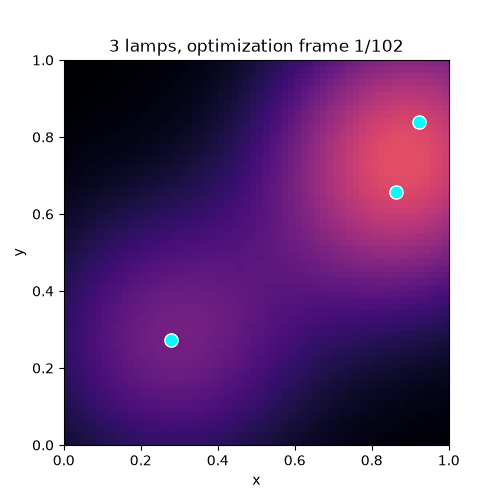

In [6]:
three_lamp_gif = save_trajectory_gif(result_3, OUTPUT_DIR / 'three_lamps.gif')
display(Image(filename=str(three_lamp_gif)))

## Do random seeds agree?

Because the objective is non-convex, different starts can reach different arrangements. The table reports final objective terms and positions for several seeds.

In [7]:
seed_results = []
for seed in range(5):
    run = optimize_lamps(num_lamps=3, seed=seed)
    value, brightness, penalty = objective(run['lamps'])
    seed_results.append({
        'seed': seed,
        'J': value.item(),
        'brightness': brightness.item(),
        'penalty': penalty.item(),
        'positions': np.round(run['lamps'].numpy(), 3).tolist(),
    })

for row in seed_results:
    print(row)

best = max(seed_results, key=lambda row: row['J'])
print(f'Best seed: {best["seed"]}; objective spread: {max(r["J"] for r in seed_results) - min(r["J"] for r in seed_results):.4f}')

{'seed': 0, 'J': 0.7905910883949961, 'brightness': 0.8410751121674016, 'penalty': 0.050484023772405476, 'positions': [[0.802, 0.602], [0.25, 0.751], [0.396, 0.198]]}
{'seed': 1, 'J': 0.7905909794391199, 'brightness': 0.8410749007573393, 'penalty': 0.050483921318219306, 'positions': [[0.199, 0.392], [0.598, 0.802], [0.753, 0.252]]}
{'seed': 2, 'J': 0.7905902788192668, 'brightness': 0.8410737930301261, 'penalty': 0.05048351421085926, 'positions': [[0.41, 0.197], [0.243, 0.743], [0.8, 0.617]]}
{'seed': 3, 'J': 0.7905878843969618, 'brightness': 0.8410726927786113, 'penalty': 0.05048480838164944, 'positions': [[0.196, 0.425], [0.735, 0.237], [0.63, 0.798]]}
{'seed': 4, 'J': 0.7905756705104727, 'brightness': 0.8410747049745223, 'penalty': 0.05049903446404952, 'positions': [[0.674, 0.79], [0.194, 0.48], [0.703, 0.219]]}
Best seed: 0; objective spread: 0.0000


## More lamps

The same objective and optimizer also produce trajectories for 4, 6, and 8 lamps. These runs use one seed each and save a GIF per lamp count.

4 lamps: J=0.9391, brightness=1.0309, penalty=0.0918, GIF=lamp_outputs\4_lamps.gif
6 lamps: J=1.0566, brightness=1.2527, penalty=0.1961, GIF=lamp_outputs\6_lamps.gif
8 lamps: J=1.0253, brightness=1.4606, penalty=0.4353, GIF=lamp_outputs\8_lamps.gif


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13436\3641239557.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


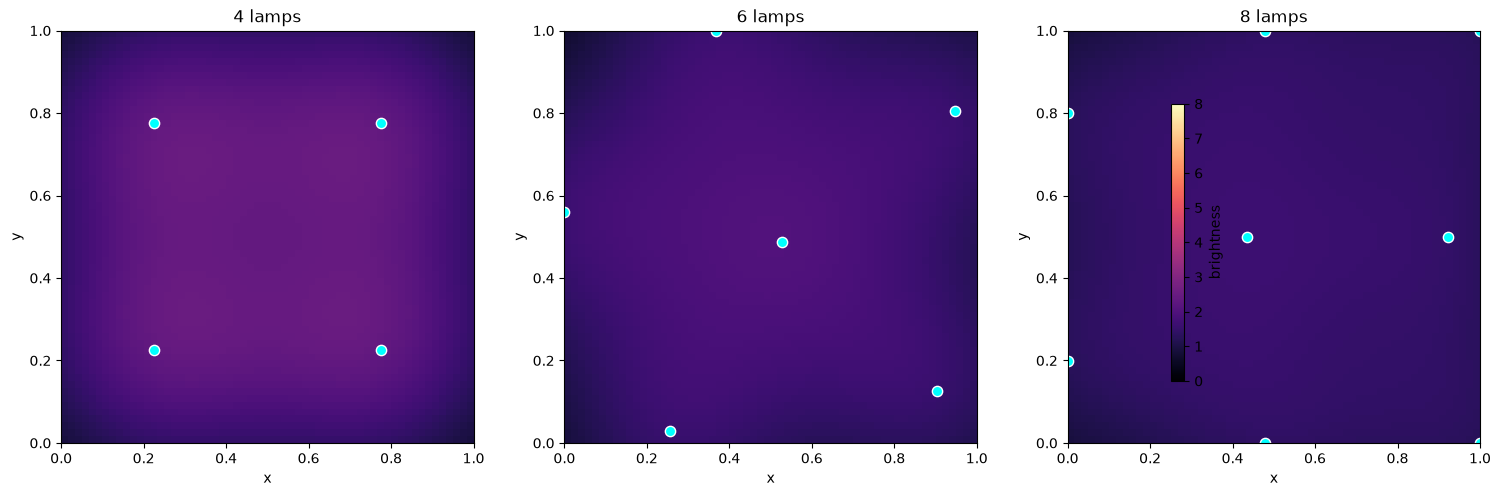

In [8]:
multi_lamp_results = {}
for num_lamps in (4, 6, 8):
    run = optimize_lamps(num_lamps=num_lamps, seed=100 + num_lamps, steps=400)
    gif_path = save_trajectory_gif(run, OUTPUT_DIR / f'{num_lamps}_lamps.gif')
    value, brightness, penalty = objective(run['lamps'])
    multi_lamp_results[num_lamps] = run
    print(f'{num_lamps} lamps: J={value.item():.4f}, brightness={brightness.item():.4f}, penalty={penalty.item():.4f}, GIF={gif_path}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, num_lamps in zip(axes, (4, 6, 8)):
    run = multi_lamp_results[num_lamps]
    image = ax.imshow(map_array(run['lamps']), origin='lower', extent=(0, 1, 0, 1), cmap='magma', vmin=0, vmax=num_lamps)
    lamps = run['lamps']
    ax.scatter(lamps[:, 0], lamps[:, 1], c='cyan', edgecolors='white', s=55)
    ax.set(xlim=(0, 1), ylim=(0, 1), title=f'{num_lamps} lamps', xlabel='x', ylabel='y')
fig.colorbar(image, ax=axes, label='brightness', shrink=0.8)
fig.tight_layout()
plt.show()

## Notes

- Increasing `sigma` spreads each lamp's light farther and reduces the importance of exact placement.
- Increasing `rho` makes the repulsion act over a larger distance.
- Setting `LAMBDA = 0` removes repulsion and demonstrates why multiple lamps may collapse to similar positions.
- The generated files are in `lamp_outputs/`: `three_lamps.gif`, `4_lamps.gif`, `6_lamps.gif`, and `8_lamps.gif`.